In [1]:
import os, glob, inspect

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug25_40k_g4lepdir_tpc_directiononly_axisloss_truevtx_nexusfeat_nooptical_ep50_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found under {RUN_DIR}"
CKPT = max(ckpts, key=os.path.getmtime)

print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("RUN_DIR   =", RUN_DIR)
print("CKPT      =", CKPT)

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})

print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

# Make sure current source is still true-vertex mode.
src = inspect.getsource(model.direction_decoder.__class__)
print("\nDirection decoder source check:")
for line in src.splitlines():
    if "v_pred" in line or "y_vtx" in line or "return evt" in line or "USE_TRUE_VERTEX_REFERENCE" in line:
        print(line)

assert "return evt.y_vtx" in src, (
    "Current direction.py is not using evt.y_vtx. "
    "Patch it back to true vertex before evaluating this true-vtx checkpoint."
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("sp_net active =", model.encoder.sp_net is not None)
print("has direction_decoder =", hasattr(model, "direction_decoder"))

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug25_40k_g4lepdir_tpc_directiononly_axisloss_truevtx_nexusfeat_nooptical_ep50_bs64_in8_sp5
RUN_DIR   = /home/apaudel/NuGraph/logs/merged1_Aug25_40k_g4lepdir_tpc_directiononly_axisloss_truevtx_nexusfeat_nooptical_ep50_bs64_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug25_40k_g4lepdir_tpc_directiononly_axisloss_truevtx_nexusfeat_nooptical_ep50_bs64_in8_sp5/version_0/checkpoints/epoch=49-step=23500.ckpt

Checkpoint hparams:
semantic_head    = False
vertex_head      = False
direction_head   = True
event_head       = False
sp_features      = 5
use_optical      = False
use_pmt_pmt      = False

Direction decoder source check:
      USE_TRUE_VERTEX_REFERENCE = True
    This uses evt.v_pred as the reference point. That is intentional for the
      USE_TRUE_VERTEX_REFERENCE = True
    USE_TRUE_VERTEX_REFERENCE = True
        if self.USE_TRUE_VERTEX_REFERENCE:
        

,N test,median axis angle deg,mean axis angle deg,p68 axis angle deg,p90 axis angle deg,median |cos axis|,mean |cos axis|,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,median |Δux|,median |Δuy|,median |Δuz|,mean |Δux|,mean |Δuy|,mean |Δuz|,stored evt.v_pred median err cm,stored evt.v_pred p68 err cm,stored evt.v_pred p90 err cm
0,1672,14.1533,17.284401,19.664801,34.352299,0.9696,0.9318,0.3295,0.6896,0.8594,0.0911,0.1099,0.1037,0.1349,0.157,0.1519,5.4797,8.1207,17.76



Axis angle between true and predicted direction:
  median = 14.15 deg
  mean   = 17.28 deg
  p68    = 19.66 deg
  p90    = 34.35 deg

Stored v_pred sanity, not used by this true-vtx model:
  stored evt.v_pred median residual = 5.48 cm


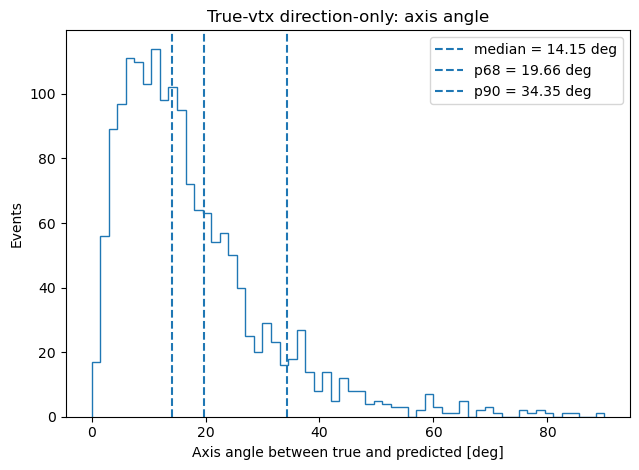

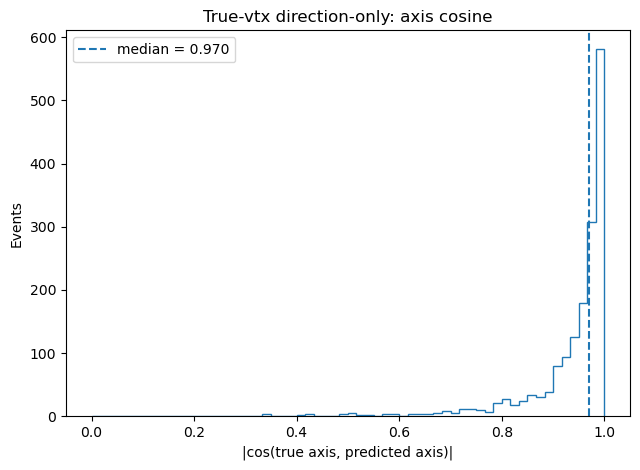

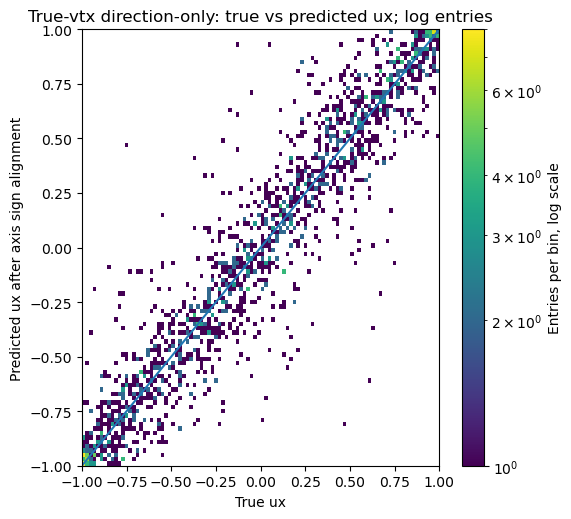

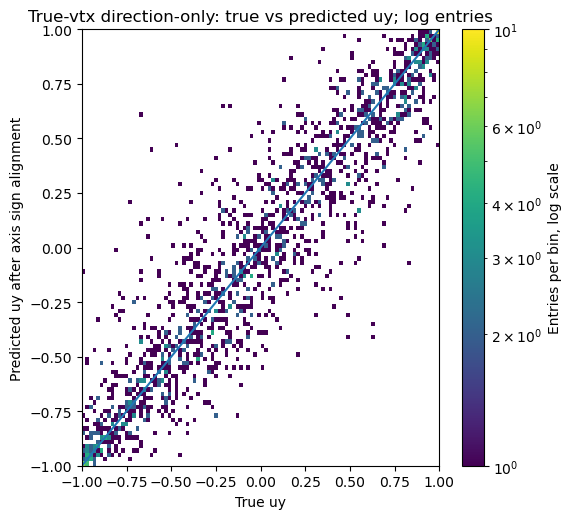

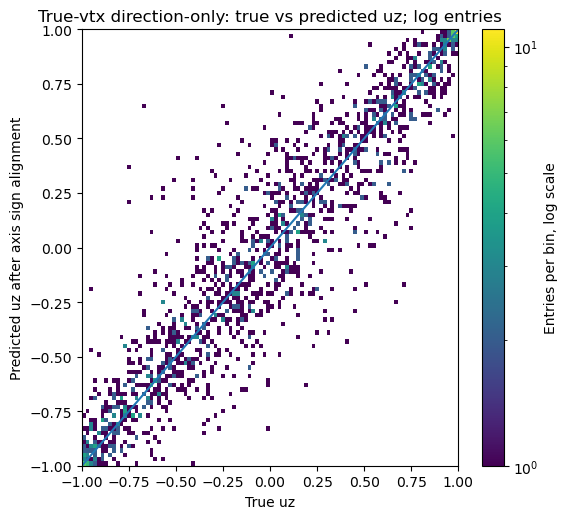

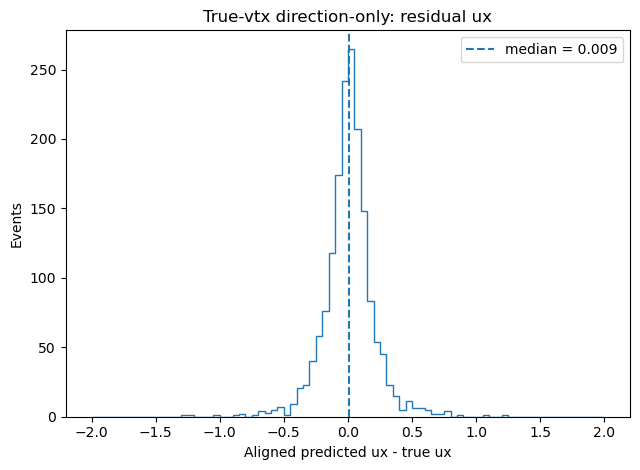

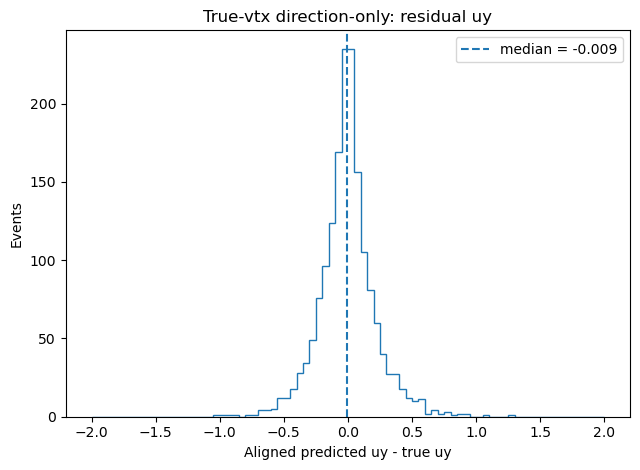

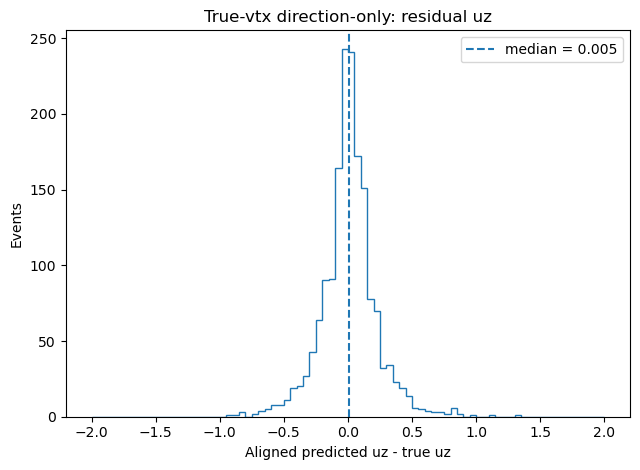

In [2]:
# ============================================================
# Evaluate true-vertex direction-only model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # Fills evt.d
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),
            "stored_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
stored_vpred = np.concatenate([r["stored_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis-loss comparison:
# u and -u are equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Global sign alignment for component plots.
axis_sign = np.where(cos_signed >= 0.0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_residual_vec = pred_axis_aligned - true_axis
axis_component_abs = np.abs(axis_residual_vec)

stored_vpred_err = np.linalg.norm(stored_vpred - true_vtx, axis=1)

# ============================================================
# Summary
# ============================================================

summary = {
    "N test": len(axis_angle_deg),

    "median axis angle deg": np.median(axis_angle_deg),
    "mean axis angle deg": np.mean(axis_angle_deg),
    "p68 axis angle deg": np.percentile(axis_angle_deg, 68),
    "p90 axis angle deg": np.percentile(axis_angle_deg, 90),

    "median |cos axis|": np.median(axis_cos),
    "mean |cos axis|": np.mean(axis_cos),

    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "median |Δux|": np.median(axis_component_abs[:, 0]),
    "median |Δuy|": np.median(axis_component_abs[:, 1]),
    "median |Δuz|": np.median(axis_component_abs[:, 2]),

    "mean |Δux|": np.mean(axis_component_abs[:, 0]),
    "mean |Δuy|": np.mean(axis_component_abs[:, 1]),
    "mean |Δuz|": np.mean(axis_component_abs[:, 2]),

    "stored evt.v_pred median err cm": np.median(stored_vpred_err),
    "stored evt.v_pred p68 err cm": np.percentile(stored_vpred_err, 68),
    "stored evt.v_pred p90 err cm": np.percentile(stored_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

print("\nAxis angle between true and predicted direction:")
print(f"  median = {np.median(axis_angle_deg):.2f} deg")
print(f"  mean   = {np.mean(axis_angle_deg):.2f} deg")
print(f"  p68    = {np.percentile(axis_angle_deg, 68):.2f} deg")
print(f"  p90    = {np.percentile(axis_angle_deg, 90):.2f} deg")

print("\nStored v_pred sanity, not used by this true-vtx model:")
print(f"  stored evt.v_pred median residual = {np.median(stored_vpred_err):.2f} cm")

# ============================================================
# Axis angle and cosine plots
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.axvline(np.median(axis_angle_deg), linestyle="--", label=f"median = {np.median(axis_angle_deg):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 68), linestyle="--", label=f"p68 = {np.percentile(axis_angle_deg, 68):.2f} deg")
plt.axvline(np.percentile(axis_angle_deg, 90), linestyle="--", label=f"p90 = {np.percentile(axis_angle_deg, 90):.2f} deg")
plt.xlabel("Axis angle between true and predicted [deg]")
plt.ylabel("Events")
plt.title("True-vtx direction-only: axis angle")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.axvline(np.median(axis_cos), linestyle="--", label=f"median = {np.median(axis_cos):.3f}")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("True-vtx direction-only: axis cosine")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# ux, uy, uz true vs predicted
# x/y axes linear, entries shown in log color scale
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.8, 5.3))

    plt.hist2d(
        true_axis[:, coord],
        pred_axis_aligned[:, coord],
        bins=100,
        range=[[-1, 1], [-1, 1]],
        norm=LogNorm(),
        cmin=1,
    )

    plt.plot([-1, 1], [-1, 1], linewidth=1.5)
    plt.xlabel(f"True u{label}")
    plt.ylabel(f"Predicted u{label} after axis sign alignment")
    plt.title(f"True-vtx direction-only: true vs predicted u{label}; log entries")
    cbar = plt.colorbar()
    cbar.set_label("Entries per bin, log scale")
    plt.tight_layout()
    plt.show()

# ============================================================
# Axis component residuals
# ============================================================

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    residual = axis_residual_vec[:, coord]

    plt.figure(figsize=(6.5, 4.8))
    plt.hist(residual, bins=80, range=(-2, 2), histtype="step")
    plt.axvline(np.median(residual), linestyle="--", label=f"median = {np.median(residual):.3f}")
    plt.xlabel(f"Aligned predicted u{label} - true u{label}")
    plt.ylabel("Events")
    plt.title(f"True-vtx direction-only: residual u{label}")
    plt.legend()
    plt.tight_layout()
    plt.show()